# 06 · Beijing PM2.5 — Spectral, Lead-Lag & Source Diagnostics

## Part 6 — Advanced Diagnostics: Spectral, Lead-Lag & Source Structure

A final layer of analysis using techniques the earlier parts didn't — looking at pollution in the
**frequency domain**, in **time-lagged** relation to weather, and as a function of **where the wind
comes from**:

1. **Spectral analysis** (the periodogram) — decompose PM2.5 into frequencies to *quantify* its
   cycles precisely, beyond what the ACF shows;
2. **Cross-correlation** — does a weather change *precede* a pollution change (an early-warning lead)?
3. **Source structure** — mean pollution by **wind direction × speed**, the meteorologist's map of
   *which* winds carry dirty air;
4. **Change-point detection** — did Beijing's pollution **structurally change** over 2010–2014?

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

g = pd.read_csv(data.DATA_PROC / "beijing_imputed.csv", parse_dates=["datetime"]).set_index("datetime")
g["pm25"] = g["pm25"].clip(lower=0)
s = g["pm25"]
print("series:", len(s), "hours |", s.index.min().date(), "->", s.index.max().date())

setup ok | numpy 2.1.3 | pandas 2.3.3
series: 43824 hours | 2010-01-01 -> 2014-12-31


### 1. Spectral analysis — the cycles, quantified

The ACF (Part 2) *showed* a daily rhythm; the **periodogram** *measures* it. It expresses the series
as a sum of sine waves and reports how much **power** sits at each frequency — sharp peaks mark the
dominant **periods**. For pollution we expect two: the **24-hour** (daily) and the **~365-day**
(annual, winter-heating) cycles — and indeed they dominate.

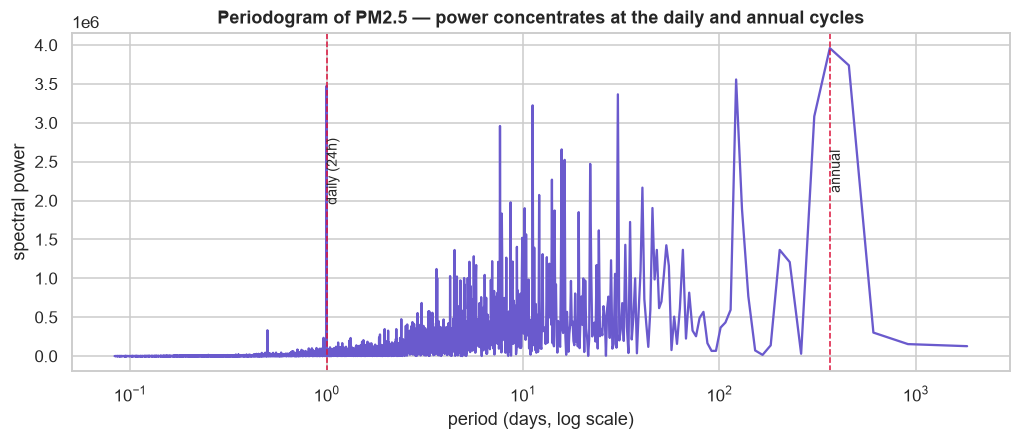

dominant periods (hours): [8764.8, 10956.0, 2921.6, 24.0] -> ['365.2d', '456.5d', '121.7d', '1.0d']


In [2]:
from scipy.signal import periodogram
f, Pxx = periodogram(s - s.mean(), fs=1.0)        # fs = 1 sample per hour
period_h = 1 / f[1:]; power = Pxx[1:]
fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogx(period_h / 24, power, color="slateblue")           # x = period in DAYS (log)
for p, lab in [(1, "daily (24h)"), (365.25, "annual")]:
    ax.axvline(p, color="crimson", ls="--", lw=1); ax.text(p, power.max()*0.6, lab, rotation=90, va="center", fontsize=9)
ax.set_xlabel("period (days, log scale)"); ax.set_ylabel("spectral power"); ax.set_title("Periodogram of PM2.5 — power concentrates at the daily and annual cycles")
eda.savefig(fig, "p6_periodogram.png"); plt.show()
top = pd.Series(power, index=period_h).sort_values(ascending=False).head(4)
print("dominant periods (hours):", [round(p, 1) for p in top.index], "->", [f"{p/24:.1f}d" for p in top.index])

### 2. Cross-correlation — does weather *lead* pollution?

The **cross-correlation function (CCF)** correlates a weather variable at time *t* with PM2.5 at
*t+k*. A peak at a **positive lag** would mean the weather change happens *first* — a usable
early-warning signal. The finding is itself instructive: pollution responds to weather almost
**within the hour** (peaks at lag 0), with only pressure leading slightly — so for forecasting you
need a *weather forecast*, not just past weather.

Iws   strongest corr -0.25 at lag 0h
DEWP  strongest corr 0.17 at lag 0h
PRES  strongest corr -0.05 at lag 5h


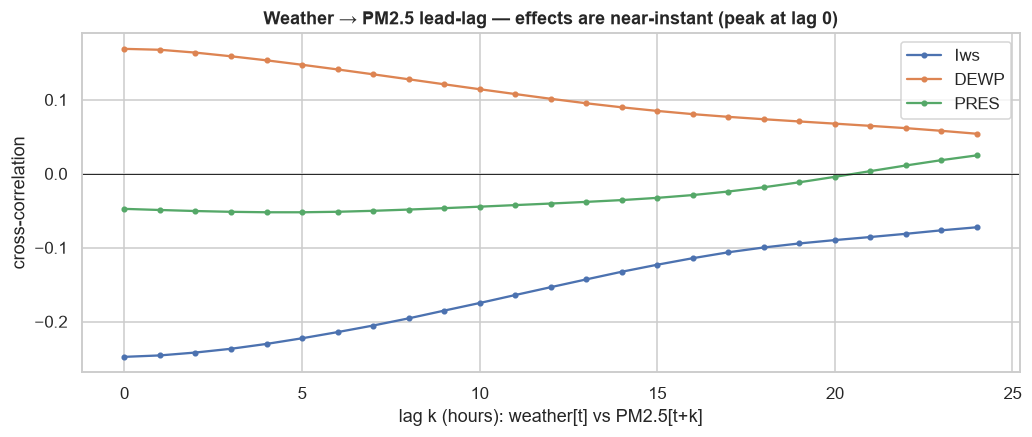

In [3]:
from statsmodels.tsa.stattools import ccf
fig, ax = plt.subplots(figsize=(11, 4))
for c in ["Iws", "DEWP", "PRES"]:
    cc = ccf(g[c] - g[c].mean(), s - s.mean(), adjusted=False)[:25]
    ax.plot(range(25), cc, "o-", ms=3, label=c)
    k = int(np.argmax(np.abs(cc)))
    print("%-5s strongest corr %.2f at lag %dh" % (c, cc[k], k))
ax.axhline(0, color="k", lw=.6); ax.set_xlabel("lag k (hours): weather[t] vs PM2.5[t+k]"); ax.set_ylabel("cross-correlation")
ax.set_title("Weather → PM2.5 lead-lag — effects are near-instant (peak at lag 0)"); ax.legend()
eda.savefig(fig, "p6_ccf.png"); plt.show()

### 3. Source structure — which winds carry the pollution?

Wind **speed** disperses pollution, but wind **direction** decides *what* it brings: clean air from
the mountains (N/NW) vs polluted air from the industrial plains (SE). A heatmap of mean PM2.5 over
**direction × speed** is the air-quality scientist's "pollution rose": it should show that strong
N-winds clear the air while **SE winds stay dirty even when strong**, and that *calm* air traps
pollution from any direction.

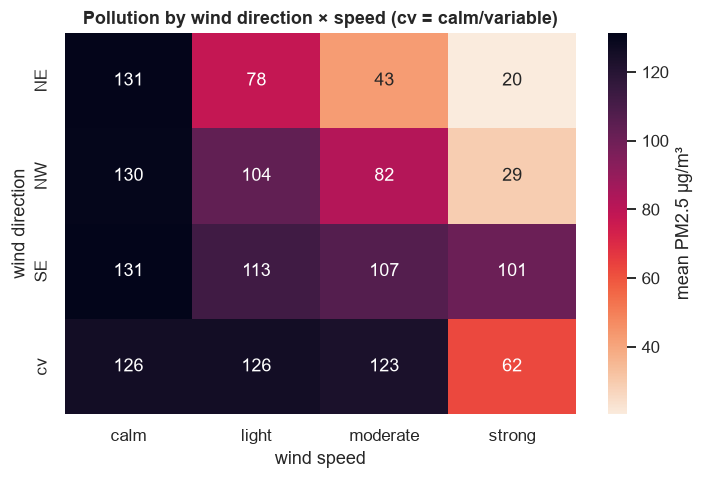

cleanest: ('NE', 'strong') wind = 20 µg/m³ | dirtiest: ('SE', 'calm') = 131
-> strong N-winds scrub the air; SE winds stay polluted even when strong (they carry it in); calm traps it.


In [4]:
g["spd"] = pd.qcut(g["Iws"], 4, labels=["calm", "light", "moderate", "strong"])
piv = g.pivot_table("pm25", "wind_dir", "spd", observed=True)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="rocket_r", ax=ax, cbar_kws={"label": "mean PM2.5 µg/m³"})
ax.set_xlabel("wind speed"); ax.set_ylabel("wind direction"); ax.set_title("Pollution by wind direction × speed (cv = calm/variable)")
eda.savefig(fig, "p6_source.png"); plt.show()
print("cleanest: %s wind = %.0f µg/m³ | dirtiest: %s = %.0f" %
      (piv.stack().idxmin(), piv.stack().min(), piv.stack().idxmax(), piv.stack().max()))
print("-> strong N-winds scrub the air; SE winds stay polluted even when strong (they carry it in); calm traps it.")

### 4. Change-point detection — did the air structurally change?

Did pollution shift to a new regime over these five years (a policy effect, say)? Raw change-point
detection would just chase the seasonal swings, so we first **deseasonalize** (subtract each month's
climatology) and run **PELT** on the monthly anomaly. The honest answer here: **no break** — Beijing's
air did **not** structurally improve over 2010–2014 (this window predates the post-2014 "war on
pollution").

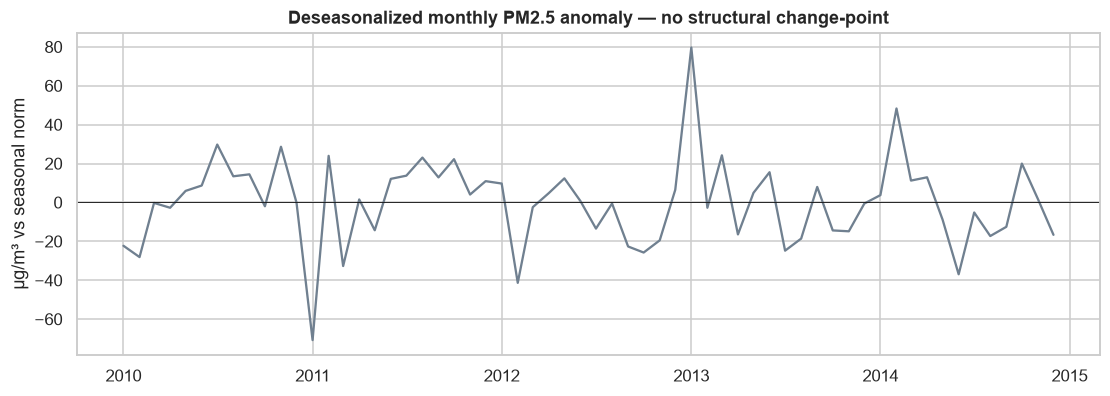

annual mean µg/m³: {2010: 102, 2011: 99, 2012: 91, 2013: 102, 2014: 98} -> flat (no improvement)


In [5]:
import ruptures as rpt
monthly = s.resample("MS").mean()
anom = (monthly - monthly.groupby(monthly.index.month).transform("mean")).dropna()
cps = rpt.Pelt(model="l2").fit(anom.values).predict(pen=np.var(anom) * 3)
breaks = [anom.index[i] for i in cps[:-1]]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(anom.index, anom.values, color="slategray"); ax.axhline(0, color="k", lw=.6)
for b in breaks: ax.axvline(b, color="crimson", ls="--")
ax.set_title("Deseasonalized monthly PM2.5 anomaly — %s" % ("breaks: " + ", ".join(b.strftime("%Y-%m") for b in breaks) if breaks else "no structural change-point"))
ax.set_ylabel("µg/m³ vs seasonal norm"); eda.savefig(fig, "p6_changepoint.png"); plt.show()
yr = s.resample("YE").mean(); print("annual mean µg/m³:", {d.year: round(v) for d, v in yr.items()}, "-> flat (no improvement)")

### Takeaways

- **Spectral analysis** confirms and *quantifies* the structure the ACF hinted at: power concentrates
  almost entirely at the **daily (24h)** and **annual** periods — the two clocks that govern pollution.
- **Cross-correlation** shows weather acts on pollution **near-instantly** (peak at lag 0) — there is
  no free early-warning lead in the weather, which is *why* useful forecasting needs a weather forecast.
- The **direction × speed** map is a genuine source-attribution finding: **strong northerly winds
  clean the air (≈20 µg/m³); south-easterly winds stay polluted even at speed (≈100) because they
  import it; calm air traps it (≈130)** regardless of direction.
- **Change-point detection** (on the deseasonalized series) finds **no regime shift** — the air did not
  structurally improve over 2010–2014, a sobering, policy-relevant result.

*This rounds out the air-quality study (Parts 0–6) with frequency-domain, lead-lag, spatial and
structural-break diagnostics — the advanced-EDA techniques that turn "looking at data" into evidence.*